# Manhattan Congestion Pricing and NYC Bus Speeds

## Core conventions

- Treatment is defined by any policy-date-active route shape intersecting the CBD geofence.
- Staten Island is excluded from the main NYC analysis.
- January 2025 is the first post-policy month.
- The analysis window is August 2023 through May 2026: 17 pre-policy and 17 post-policy months.
- Weekdays are the primary sample.
- The main estimand uses the 263-route propensity-score common-support sample: 81 treated and 182 control routes.

### Navigation

- [Part I: Main NYC difference-in-differences](#Part-I.-Main-NYC-Difference-in-Differences)
- [Part II: Robustness and Boston stress test](#Part-II.-NYC-Robustness-and-Boston-External-Control-Stress-Test)
- [Part III: NTD synthetic control](#Part-III.-NYC-CBD-Synthetic-Control-with-NTD-Donor-Agencies)

## Part I. Main NYC Difference-in-Differences

This notebook estimates the change in NYC bus speeds associated with congestion pricing.The analysis proceeds in four steps: descriptive analysis, assumption checks, estimation on routes with common propensity-score support, and presentation of the results.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import minimize
from shapely import wkt
from shapely.ops import unary_union

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL_PATH = ROOT / "data" / "processed" / "nyc_did_panel_geojson_intersection.csv"
ROUTES_PATH = ROOT / "data" / "raw" / "NYC" / "nyc_bus_routes_20260706.geojson"
GEOFENCE_PATH = ROOT / "data" / "raw" / "NYC" / "nyc_cbd_geofence.csv"
NTD_PANEL_PATH = ROOT / "data" / "processed" / "ntd_monthly_bus_speeds.csv"
NTD_DONOR_POOL_PATH = ROOT / "outputs" / "tables" / "ntd_synthetic_control_donor_pool.csv"
SYSTEMWIDE_SPILLOVER_SUMMARY = ROOT / "outputs" / "tables" / "nyc_control_network_synthetic_spillover_summary.csv"
SYSTEMWIDE_SPILLOVER_MONTHLY = ROOT / "outputs" / "tables" / "nyc_control_network_synthetic_spillover_monthly.csv"
SYSTEMWIDE_SPILLOVER_PLACEBOS = ROOT / "outputs" / "tables" / "nyc_control_network_synthetic_spillover_placebos.csv"
SYSTEMWIDE_SPILLOVER_TEST = ROOT / "outputs" / "tables" / "nyc_control_network_synthetic_spillover_placebo_test.csv"
POLICY_MONTH = pd.Timestamp("2025-01-01")
POLICY_DATE = pd.Timestamp("2025-01-05")

plt.style.use("seaborn-v0_8-whitegrid")

### Exploratory data analysis

In [2]:
df = pd.read_csv(PANEL_PATH)
df["month"] = pd.to_datetime(df["month"])
df["month_str"] = df["month"].dt.to_period("M").astype(str)
df["treated"] = df["cbd_route"].astype(int)
df["post_int"] = df["post"].astype(int)
df["did"] = df["treated"] * df["post_int"]

panel_summary = pd.Series({
    "rows": len(df),
    "routes": df["route_id"].nunique(),
    "months": df["month"].nunique(),
    "pre_months": df.loc[df["month"] < POLICY_MONTH, "month"].nunique(),
    "post_months": df.loc[df["month"] >= POLICY_MONTH, "month"].nunique(),
    "treated_routes": df.loc[df["treated"].eq(1), "route_id"].nunique(),
    "control_routes": df.loc[df["treated"].eq(0), "route_id"].nunique(),
})

print(f"Analysis window: {df['month'].min().date()} to {df['month'].max().date()}")
display(panel_summary.to_frame("value"))

Analysis window: 2023-08-01 to 2026-05-01


,value
rows,36077
routes,305
months,34
pre_months,17
post_months,17
treated_routes,84
control_routes,221


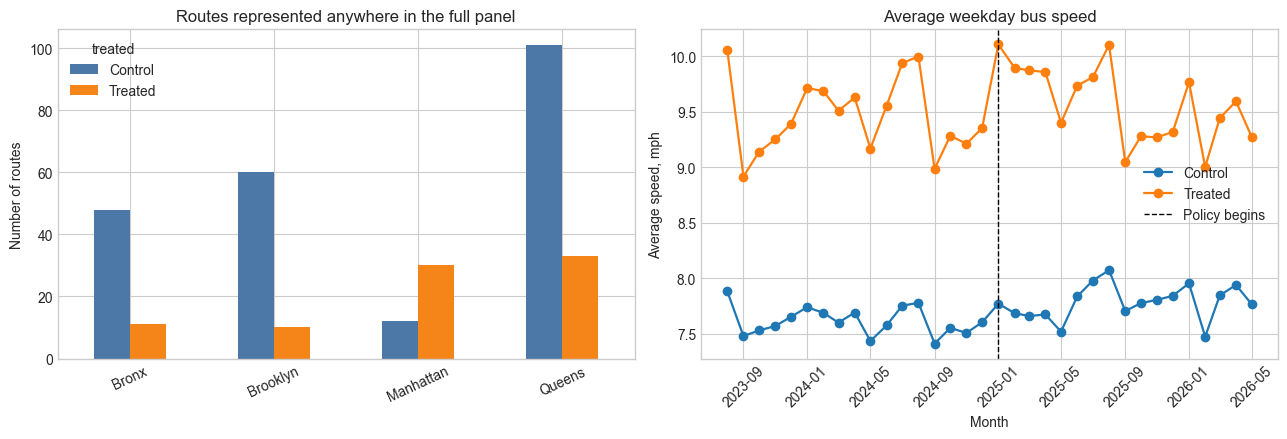

,treated,post_int,mean_speed,observations
0,Control,Pre,7.612,6570
1,Control,Post,7.783,6953
2,Treated,Pre,9.456,2835
3,Treated,Post,9.578,2750


In [3]:
route_borough = df[["route_id", "borough", "treated"]].drop_duplicates()
route_counts = (
    route_borough.groupby(["borough", "treated"])["route_id"]
    .nunique()
    .unstack(fill_value=0)
    .rename(columns={0: "Control", 1: "Treated"})
)

trend = (
    df.query("day_type == 1")
    .groupby(["month", "treated"], as_index=False)["average_speed"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
route_counts.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Routes represented anywhere in the full panel")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of routes")
axes[0].tick_params(axis="x", rotation=25)

for treated_value, group in trend.groupby("treated"):
    label = "Treated" if treated_value else "Control"
    axes[1].plot(group["month"], group["average_speed"], marker="o", linewidth=1.6, label=label)
axes[1].axvline(POLICY_MONTH, color="black", linestyle="--", linewidth=1, label="Policy begins")
axes[1].set_title("Average weekday bus speed")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average speed, mph")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

prepost_means = (
    df.query("day_type == 1")
    .groupby(["treated", "post_int"], observed=True)["average_speed"]
    .agg(mean_speed="mean", observations="size")
    .reset_index()
    .replace({"treated": {0: "Control", 1: "Treated"}, "post_int": {0: "Pre", 1: "Post"}})
)
display(prepost_means.round(3))

### Assumption testing

#### Overlap

The EDA above counts every route represented anywhere in the full panel (221 controls and 84 treated). The overlap model has a narrower eligibility requirement because its covariates must be measured before treatment on weekdays. Of the 221 control routes, 4 have no weekday observations and 25 first appear only after January 2025, leaving 192 controls eligible to receive a propensity score. A route-level logistic model predicts CBD exposure using borough, pre-policy weekday mean speed, speed variability, and speed trend. The common-support interval is the intersection of the treated and control propensity-score ranges; 10 eligible controls and 3 treated routes lie outside it. The final analysis sample therefore contains 182 controls and 81 treated routes.

,group,full_panel_routes,pre_weekday_eligible_routes,minimum_score,maximum_score,outside_common_support,retained_in_common_support
0,Control,221,192,0.008,0.995,10,182
1,Treated,84,84,0.020,0.998,3,81


Common support: [0.020, 0.995]
Analysis sample after trimming: 263 routes (81 treated, 182 control)


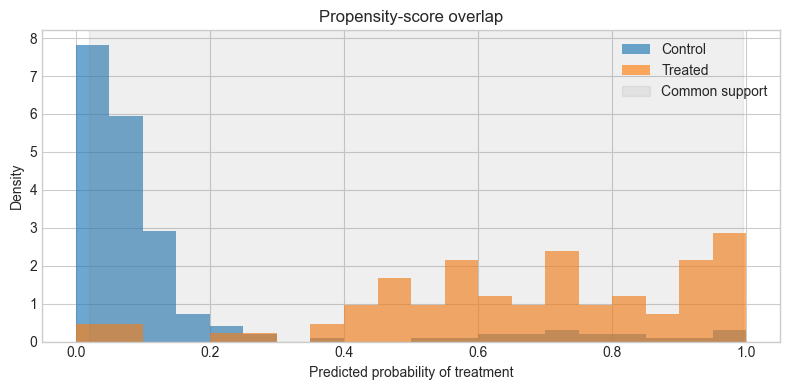

In [4]:
pre_weekday = df.query("day_type == 1 and month < @POLICY_MONTH").copy()
pre_route_month = (
    pre_weekday.groupby(["route_id", "month"], as_index=False)["average_speed"]
    .mean()
)
pre_slopes = (
    pre_route_month.sort_values(["route_id", "month"])
    .groupby("route_id")["average_speed"]
    .apply(lambda values: np.polyfit(np.arange(len(values)), values, 1)[0])
    .rename("pre_speed_slope")
)

route_overlap = (
    pre_weekday.groupby("route_id", as_index=False)
    .agg(
        treated=("treated", "first"),
        borough=("borough", "first"),
        pre_mean_speed=("average_speed", "mean"),
        pre_sd_speed=("average_speed", "std"),
    )
    .merge(pre_slopes, on="route_id", how="left")
)

continuous_predictors = ["pre_mean_speed", "pre_sd_speed", "pre_speed_slope"]
for column in continuous_predictors:
    route_overlap[f"z_{column}"] = (
        route_overlap[column] - route_overlap[column].mean()
    ) / route_overlap[column].std()

propensity_model = smf.glm(
    "treated ~ z_pre_mean_speed + z_pre_sd_speed + z_pre_speed_slope + C(borough)",
    data=route_overlap,
    family=sm.families.Binomial(),
).fit()
route_overlap["propensity_score"] = propensity_model.predict(route_overlap)

treated_scores = route_overlap.loc[route_overlap["treated"].eq(1), "propensity_score"]
control_scores = route_overlap.loc[route_overlap["treated"].eq(0), "propensity_score"]
support_low = max(treated_scores.min(), control_scores.min())
support_high = min(treated_scores.max(), control_scores.max())
route_overlap["in_common_support"] = route_overlap["propensity_score"].between(
    support_low, support_high
)

common_support_routes = set(
    route_overlap.loc[route_overlap["in_common_support"], "route_id"]
)
analysis_all = df.loc[df["route_id"].isin(common_support_routes)].copy()
analysis_weekday = analysis_all.query("day_type == 1").copy()
outside_support = route_overlap.loc[~route_overlap["in_common_support"]].copy()

overlap_summary = pd.DataFrame({
    "group": ["Control", "Treated"],
    "full_panel_routes": [
        df.loc[df["treated"].eq(0), "route_id"].nunique(),
        df.loc[df["treated"].eq(1), "route_id"].nunique(),
    ],
    "pre_weekday_eligible_routes": [len(control_scores), len(treated_scores)],
    "minimum_score": [control_scores.min(), treated_scores.min()],
    "maximum_score": [control_scores.max(), treated_scores.max()],
    "outside_common_support": [
        int((outside_support["treated"] == 0).sum()),
        int((outside_support["treated"] == 1).sum()),
    ],
    "retained_in_common_support": [
        int((route_overlap["in_common_support"] & route_overlap["treated"].eq(0)).sum()),
        int((route_overlap["in_common_support"] & route_overlap["treated"].eq(1)).sum()),
    ],
})

display(overlap_summary.round(3))
print(f"Common support: [{support_low:.3f}, {support_high:.3f}]")
print(
    f"Analysis sample after trimming: {analysis_weekday['route_id'].nunique():,} routes "
    f"({analysis_weekday.loc[analysis_weekday['treated'].eq(1), 'route_id'].nunique():,} treated, "
    f"{analysis_weekday.loc[analysis_weekday['treated'].eq(0), 'route_id'].nunique():,} control)"
)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 21)
ax.hist(control_scores, bins=bins, alpha=0.65, density=True, label="Control")
ax.hist(treated_scores, bins=bins, alpha=0.65, density=True, label="Treated")
ax.axvspan(support_low, support_high, color="grey", alpha=0.12, label="Common support")
ax.set_title("Propensity-score overlap")
ax.set_xlabel("Predicted probability of treatment")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
plt.show()

#### Parallel trends

Parallel trends are assessed on the same common-support weekday sample used for the DiD. The event-study coefficients compare treated and control routes in each pre-policy month relative to December 2024. A joint test evaluates whether all lead coefficients are zero, while a linear interaction summarizes the average differential monthly trend.

,diagnostic,estimate,std_error,p_value,ci_low,ci_high
0,Joint event-study leads,NaN,NaN,0.0000,NaN,NaN
1,Linear differential trend (mph/month),0.0034,0.002,0.0944,-0.0006,0.0074


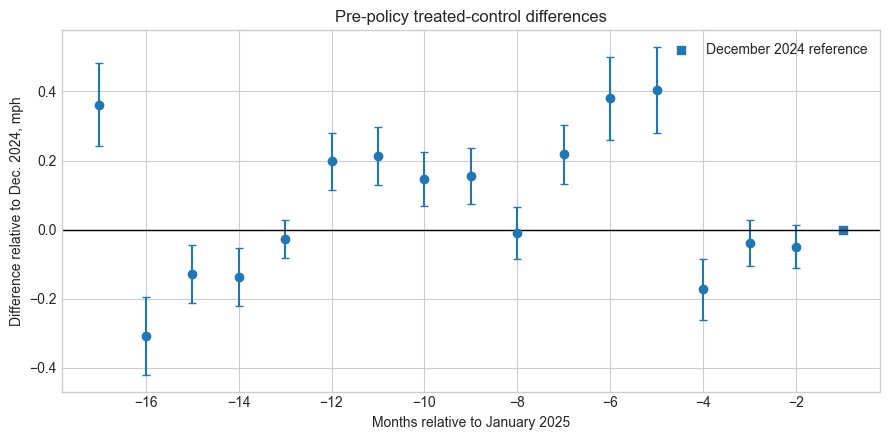

The joint test rejects zero pre-policy lead coefficients.


In [5]:
pt = analysis_weekday.copy()
pt["rel_month"] = (
    (pt["month"].dt.year - POLICY_MONTH.year) * 12
    + (pt["month"].dt.month - POLICY_MONTH.month)
).astype(int)
pre_pt = pt.loc[pt["rel_month"].between(-17, -1)].copy()
reference_month = -1
lead_months = [month for month in sorted(pre_pt["rel_month"].unique()) if month != reference_month]
lead_columns = []

for month in lead_months:
    column = f"treated_rel_{abs(month)}"
    pre_pt[column] = (
        pre_pt["treated"].eq(1) & pre_pt["rel_month"].eq(month)
    ).astype(int)
    lead_columns.append(column)

lead_model = smf.ols(
    "average_speed ~ " + " + ".join(lead_columns)
    + " + C(route_id) + C(month_str) + C(period)",
    data=pre_pt,
).fit(cov_type="cluster", cov_kwds={"groups": pre_pt["route_id"]})

lead_results = pd.DataFrame([
    {
        "rel_month": month,
        "estimate_mph": lead_model.params[column],
        "ci_low": lead_model.conf_int().loc[column, 0],
        "ci_high": lead_model.conf_int().loc[column, 1],
    }
    for month, column in zip(lead_months, lead_columns)
])
joint_test = lead_model.f_test(
    ", ".join(f"{column} = 0" for column in lead_columns)
)
joint_p_value = float(np.asarray(joint_test.pvalue).squeeze())

linear_pre = pre_pt.copy()
linear_pre["treated_time"] = linear_pre["treated"] * linear_pre["rel_month"]
linear_model = smf.ols(
    "average_speed ~ treated_time + C(route_id) + C(month_str) + C(period)",
    data=linear_pre,
).fit(cov_type="cluster", cov_kwds={"groups": linear_pre["route_id"]})
linear_ci = linear_model.conf_int().loc["treated_time"]

parallel_trends_summary = pd.DataFrame([
    {
        "diagnostic": "Joint event-study leads",
        "estimate": np.nan,
        "std_error": np.nan,
        "p_value": joint_p_value,
        "ci_low": np.nan,
        "ci_high": np.nan,
    },
    {
        "diagnostic": "Linear differential trend (mph/month)",
        "estimate": linear_model.params["treated_time"],
        "std_error": linear_model.bse["treated_time"],
        "p_value": linear_model.pvalues["treated_time"],
        "ci_low": linear_ci.iloc[0],
        "ci_high": linear_ci.iloc[1],
    },
])
display(parallel_trends_summary.round(4))

plot_leads = pd.concat([
    lead_results,
    pd.DataFrame([{"rel_month": -1, "estimate_mph": 0.0, "ci_low": 0.0, "ci_high": 0.0}]),
]).sort_values("rel_month")
non_reference = plot_leads["rel_month"] != -1

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(
    plot_leads.loc[non_reference, "rel_month"],
    plot_leads.loc[non_reference, "estimate_mph"],
    yerr=[
        plot_leads.loc[non_reference, "estimate_mph"] - plot_leads.loc[non_reference, "ci_low"],
        plot_leads.loc[non_reference, "ci_high"] - plot_leads.loc[non_reference, "estimate_mph"],
    ],
    fmt="o",
    capsize=3,
)
ax.scatter([-1], [0], marker="s", label="December 2024 reference")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Pre-policy treated-control differences")
ax.set_xlabel("Months relative to January 2025")
ax.set_ylabel("Difference relative to Dec. 2024, mph")
ax.legend()
fig.tight_layout()
plt.show()

if joint_p_value < 0.05:
    print("The joint test rejects zero pre-policy lead coefficients.")
else:
    print("The joint test does not reject zero pre-policy lead coefficients.")

In the common-support sample, the linear differential trend is **+0.0034 mph per month** (p = 0.094), so it is not statistically distinguishable from zero at the 5% level. However, the joint event-study test strongly rejects zero pre-policy lead coefficients (p < 0.001). The month-specific pre-policy differences therefore remain a meaningful concern even though there is no clear constant linear divergence.

#### No interference

To assess local spillovers without imposing a distance cutoff, the test uses all common-support control routes with policy-date geometry. It estimates whether their post-policy speed changes vary with minimum distance from the congestion zone. A zero distance-by-post coefficient is consistent with negligible local interference. 

,term,estimate_mph_per_km,std_error,p_value,ci_low,ci_high
0,Distance to CBD (km) ? post,0.0007,0.0037,0.8598,-0.0066,0.0079


Control routes included: 182; without policy-date geometry: 0


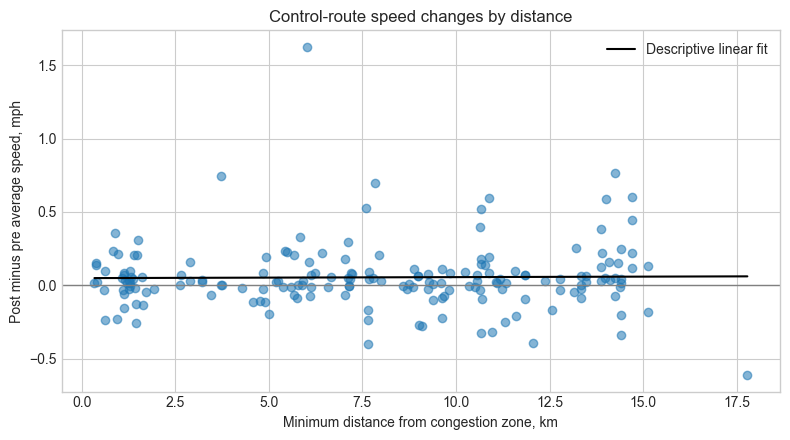

In [6]:
ACTIVE_SHAPES_WHERE = (
    "valid_from <= '2025-01-05' "
    "AND (valid_to IS NULL OR valid_to >= '2025-01-05')"
)
geofence = pd.read_csv(GEOFENCE_PATH)
cbd_wgs84 = gpd.GeoSeries(
    [unary_union([wkt.loads(value) for value in geofence["polygon"].dropna()])],
    crs="EPSG:4326",
)
cbd_2263 = cbd_wgs84.to_crs("EPSG:2263")

# GeoJSON lacks an index, so this policy-date filter still requires a sequential scan.
active_shapes = gpd.read_file(
    ROUTES_PATH,
    engine="pyogrio",
    columns=["route_id", "valid_from", "valid_to"],
    where=ACTIVE_SHAPES_WHERE,
)
active_shapes["route_id"] = active_shapes["route_id"].astype("string").str.strip().str.upper()
active_shapes = active_shapes.to_crs("EPSG:2263")
active_shapes["distance_to_cbd_km"] = (
    active_shapes.geometry.distance(cbd_2263.iloc[0]) * 0.3048 / 1_000
)

analysis_control_ids = set(
    route_overlap.loc[
        route_overlap["in_common_support"] & route_overlap["treated"].eq(0),
        "route_id",
    ]
)
control_distances = (
    active_shapes.loc[active_shapes["route_id"].isin(analysis_control_ids)]
    .groupby("route_id", as_index=False)["distance_to_cbd_km"]
    .min()
)
spillover_sample = (
    analysis_weekday.query("treated == 0")
    .merge(control_distances, on="route_id", how="inner")
    .copy()
)
spillover_sample["distance_post"] = (
    spillover_sample["distance_to_cbd_km"] * spillover_sample["post_int"]
)

spillover_model = smf.ols(
    "average_speed ~ distance_post + C(route_id) + C(month_str) + C(period)",
    data=spillover_sample,
).fit(cov_type="cluster", cov_kwds={"groups": spillover_sample["route_id"]})
spillover_ci = spillover_model.conf_int().loc["distance_post"]
spillover_result = pd.DataFrame([{
    "term": "Distance to CBD (km) ? post",
    "estimate_mph_per_km": spillover_model.params["distance_post"],
    "std_error": spillover_model.bse["distance_post"],
    "p_value": spillover_model.pvalues["distance_post"],
    "ci_low": spillover_ci.iloc[0],
    "ci_high": spillover_ci.iloc[1],
}])
display(spillover_result.round(4))
print(
    f"Control routes included: {control_distances['route_id'].nunique():,}; "
    f"without policy-date geometry: {len(analysis_control_ids) - control_distances['route_id'].nunique():,}"
)

control_change = (
    spillover_sample.groupby(["route_id", "distance_to_cbd_km", "post_int"])["average_speed"]
    .mean()
    .unstack("post_int")
    .dropna()
    .rename(columns={0: "pre_speed", 1: "post_speed"})
    .reset_index()
)
control_change["speed_change"] = control_change["post_speed"] - control_change["pre_speed"]
line_x = np.linspace(control_change["distance_to_cbd_km"].min(), control_change["distance_to_cbd_km"].max(), 100)
line_fit = np.polyfit(control_change["distance_to_cbd_km"], control_change["speed_change"], 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(control_change["distance_to_cbd_km"], control_change["speed_change"], alpha=0.55)
ax.plot(line_x, np.polyval(line_fit, line_x), color="black", linewidth=1.5, label="Descriptive linear fit")
ax.axhline(0, color="grey", linewidth=1)
ax.set_title("Control-route speed changes by distance")
ax.set_xlabel("Minimum distance from congestion zone, km")
ax.set_ylabel("Post minus pre average speed, mph")
ax.legend()
fig.tight_layout()
plt.show()

The estimated distance gradient is **+0.0007 mph per km**, with a 95% confidence interval of **[-0.0066, 0.0079]**. This is close to zero and provides no evidence that control-route changes vary systematically with proximity to the congestion zone. 

#### System-wide spillovers

We aggregate the 182 common-support control routes into a weekday monthly network-speed series and compare it with a synthetic control formed from the same 35 non-NYC NTD donor agencies used in the synthetic-control robustness notebook. Both the NYC and donor series are centered on their own pre-policy means, and donor weights are nonnegative and sum to one.

A positive post-policy gap would be consistent with a shared improvement among NYC control routes that the within-NYC DiD cannot detect.

,comparison,control_routes,donor_pool_size,pre_rmspe,post_mean_gap_mph,post_mean_control_change_mph,post_mean_synthetic_change_mph
0,NYC common-support control-route network vs sy...,182,35,0.0787,0.1221,0.0369,-0.0852


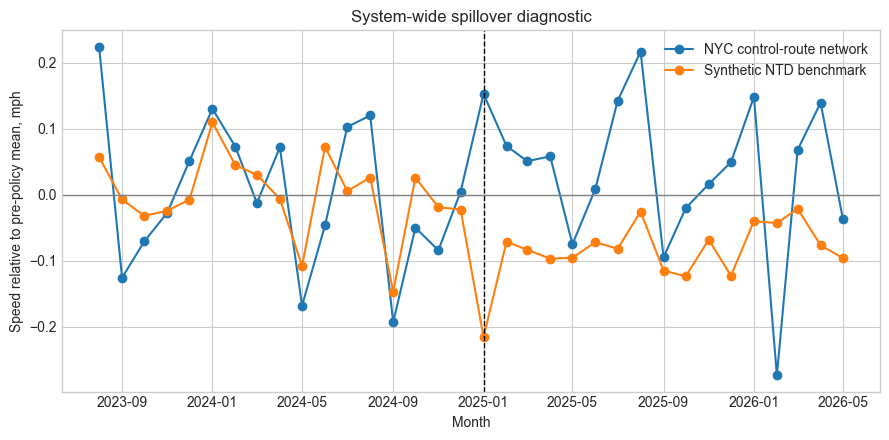

In [7]:
control_network_rows = analysis_weekday.query("treated == 0").copy()
for column in ["total_mileage", "total_operating_time"]:
    control_network_rows[column] = pd.to_numeric(
        control_network_rows[column].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )

control_network = (
    control_network_rows.groupby("month", as_index=False)
    .agg(
        total_mileage=("total_mileage", "sum"),
        total_operating_time=("total_operating_time", "sum"),
        route_count=("route_id", "nunique"),
    )
)
control_network["average_speed"] = (
    control_network["total_mileage"] / control_network["total_operating_time"]
)
control_network["unit_id"] = "NYC_CONTROL_ROUTES"

ntd_monthly = pd.read_csv(NTD_PANEL_PATH, dtype={"ntd_id": "string"})
ntd_monthly["month"] = pd.to_datetime(ntd_monthly["month"])
ntd_monthly["ntd_id"] = ntd_monthly["ntd_id"].str.zfill(5)
donor_pool = pd.read_csv(NTD_DONOR_POOL_PATH, dtype={"ntd_id": "string"})
donor_ids = donor_pool["ntd_id"].str.zfill(5).tolist()

donor_panel = (
    ntd_monthly.loc[
        ntd_monthly["ntd_id"].isin(donor_ids),
        ["month", "ntd_id", "average_speed"],
    ]
    .rename(columns={"ntd_id": "unit_id"})
    .copy()
)
spillover_synth_panel = pd.concat(
    [control_network[["month", "unit_id", "average_speed"]], donor_panel],
    ignore_index=True,
)
pre_mask = spillover_synth_panel["month"].lt(POLICY_MONTH)
pre_means = spillover_synth_panel.loc[pre_mask].groupby("unit_id")["average_speed"].mean()
spillover_synth_panel["centered_speed"] = (
    spillover_synth_panel["average_speed"]
    - spillover_synth_panel["unit_id"].map(pre_means)
)
spillover_wide = (
    spillover_synth_panel.pivot(index="month", columns="unit_id", values="centered_speed")
    .sort_index()
)
spillover_pre = spillover_wide.index < POLICY_MONTH
y_control_pre = spillover_wide.loc[spillover_pre, "NYC_CONTROL_ROUTES"].to_numpy()
x_donors_pre = spillover_wide.loc[spillover_pre, donor_ids].to_numpy()

def spillover_objective(weights):
    residual = y_control_pre - x_donors_pre @ weights
    return float(np.mean(residual ** 2))

initial_weights = np.repeat(1 / len(donor_ids), len(donor_ids))
spillover_fit = minimize(
    spillover_objective,
    initial_weights,
    method="SLSQP",
    bounds=[(0, 1)] * len(donor_ids),
    constraints={"type": "eq", "fun": lambda weights: weights.sum() - 1},
)
if not spillover_fit.success:
    raise RuntimeError(f"Synthetic spillover optimization failed: {spillover_fit.message}")
spillover_weights = np.where(spillover_fit.x < 1e-10, 0, spillover_fit.x)
spillover_weights = spillover_weights / spillover_weights.sum()

spillover_monthly = pd.DataFrame({
    "month": spillover_wide.index,
    "control_centered_speed": spillover_wide["NYC_CONTROL_ROUTES"].to_numpy(),
    "synthetic_centered_speed": spillover_wide[donor_ids].to_numpy() @ spillover_weights,
})
spillover_monthly["gap_mph"] = (
    spillover_monthly["control_centered_speed"]
    - spillover_monthly["synthetic_centered_speed"]
)
spillover_monthly["post"] = spillover_monthly["month"].ge(POLICY_MONTH)

spillover_summary = pd.DataFrame([{
    "comparison": "NYC common-support control-route network vs synthetic NTD agencies",
    "control_routes": control_network_rows["route_id"].nunique(),
    "donor_pool_size": len(donor_ids),
    "pre_rmspe": np.sqrt(
        np.mean(spillover_monthly.loc[~spillover_monthly["post"], "gap_mph"] ** 2)
    ),
    "post_mean_gap_mph": spillover_monthly.loc[
        spillover_monthly["post"], "gap_mph"
    ].mean(),
    "post_mean_control_change_mph": spillover_monthly.loc[
        spillover_monthly["post"], "control_centered_speed"
    ].mean(),
    "post_mean_synthetic_change_mph": spillover_monthly.loc[
        spillover_monthly["post"], "synthetic_centered_speed"
    ].mean(),
}])
spillover_summary.to_csv(SYSTEMWIDE_SPILLOVER_SUMMARY, index=False)
spillover_monthly.to_csv(SYSTEMWIDE_SPILLOVER_MONTHLY, index=False)
display(spillover_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    spillover_monthly["month"],
    spillover_monthly["control_centered_speed"],
    marker="o",
    label="NYC control-route network",
)
ax.plot(
    spillover_monthly["month"],
    spillover_monthly["synthetic_centered_speed"],
    marker="o",
    label="Synthetic NTD benchmark",
)
ax.axvline(POLICY_MONTH, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="grey", linewidth=1)
ax.set_title("System-wide spillover diagnostic")
ax.set_xlabel("Month")
ax.set_ylabel("Speed relative to pre-policy mean, mph")
ax.legend()
fig.tight_layout()
plt.show()

The NYC control-route network is **0.122 mph above its synthetic NTD benchmark on average after January 2025**, while the pre-period RMSPE is **0.079 mph**. The positive gap is consistent with a modest system-wide improvement, but its magnitude alone does not show whether it is unusually large relative to synthetic-control prediction error. We therefore evaluate it using in-space placebo inference below.

##### In-space placebo inference

For each NTD donor agency, we repeat the analysis while treating that agency as if it received the policy and constructing its synthetic control from the other 34 donors. The test statistic is the signed post-policy mean gap divided by the pre-policy RMSPE. This normalization accounts for differences in pre-policy fit. Following a rule selected before inspecting the placebo results, we retain placebo units with pre-period RMSPE no greater than five times NYC's pre-period RMSPE. The one-sided test asks whether NYC has an unusually large positive gap; the two-sided test uses the absolute normalized gap.

,observed_post_mean_gap_mph,observed_pre_rmspe,observed_normalized_signed_gap,rmspe_filter_multiple,eligible_placebos,excluded_placebos,one_sided_p_value,two_sided_p_value
0,0.1221,0.0787,1.5514,5,33,2,0.3529,0.6471


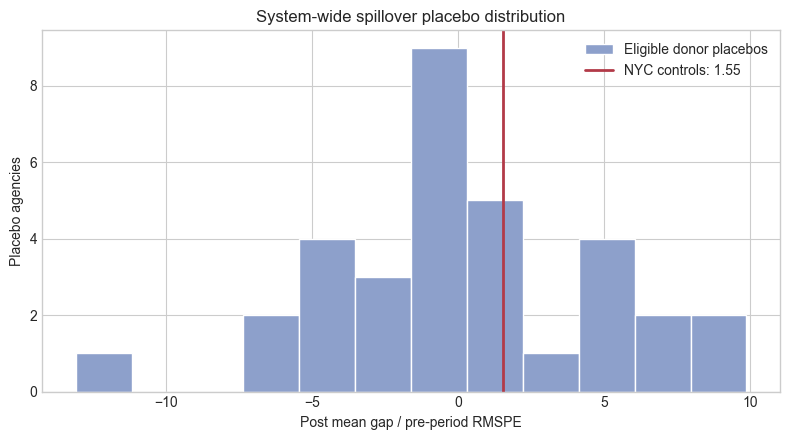

In [8]:
def fit_placebo_synthetic(treated_unit, comparison_units):
    y_pre = spillover_wide.loc[spillover_pre, treated_unit].to_numpy()
    x_pre = spillover_wide.loc[spillover_pre, comparison_units].to_numpy()

    def objective(weights):
        residual = y_pre - x_pre @ weights
        return float(np.mean(residual ** 2))

    initial = np.repeat(1 / len(comparison_units), len(comparison_units))
    fit = minimize(
        objective,
        initial,
        method="SLSQP",
        bounds=[(0, 1)] * len(comparison_units),
        constraints={"type": "eq", "fun": lambda weights: weights.sum() - 1},
    )
    if not fit.success:
        raise RuntimeError(f"Placebo optimization failed for {treated_unit}: {fit.message}")
    weights = np.where(fit.x < 1e-10, 0, fit.x)
    weights = weights / weights.sum()
    gap = (
        spillover_wide[treated_unit].to_numpy()
        - spillover_wide[comparison_units].to_numpy() @ weights
    )
    pre_rmspe = float(np.sqrt(np.mean(gap[spillover_pre] ** 2)))
    post_mean_gap = float(np.mean(gap[~spillover_pre]))
    return pre_rmspe, post_mean_gap

observed_pre_rmspe = float(spillover_summary.loc[0, "pre_rmspe"])
observed_post_gap = float(spillover_summary.loc[0, "post_mean_gap_mph"])
observed_statistic = observed_post_gap / observed_pre_rmspe

placebo_rows = []
for placebo_id in donor_ids:
    placebo_pre_rmspe, placebo_post_gap = fit_placebo_synthetic(
        placebo_id,
        [donor_id for donor_id in donor_ids if donor_id != placebo_id],
    )
    placebo_rows.append({
        "ntd_id": placebo_id,
        "pre_rmspe": placebo_pre_rmspe,
        "post_mean_gap_mph": placebo_post_gap,
        "normalized_signed_gap": placebo_post_gap / placebo_pre_rmspe,
        "normalized_absolute_gap": abs(placebo_post_gap) / placebo_pre_rmspe,
    })

placebo_results = pd.DataFrame(placebo_rows).merge(
    donor_pool[["ntd_id", "Agency"]].assign(
        ntd_id=lambda data: data["ntd_id"].str.zfill(5)
    ),
    on="ntd_id",
    how="left",
)
fit_threshold = 5 * observed_pre_rmspe
placebo_results["eligible_pre_fit"] = placebo_results["pre_rmspe"].le(fit_threshold)
eligible_placebos = placebo_results.loc[placebo_results["eligible_pre_fit"]].copy()

one_sided_p_value = (
    1 + eligible_placebos["normalized_signed_gap"].ge(observed_statistic).sum()
) / (1 + len(eligible_placebos))
two_sided_p_value = (
    1 + eligible_placebos["normalized_absolute_gap"].ge(abs(observed_statistic)).sum()
) / (1 + len(eligible_placebos))

placebo_test = pd.DataFrame([{
    "observed_post_mean_gap_mph": observed_post_gap,
    "observed_pre_rmspe": observed_pre_rmspe,
    "observed_normalized_signed_gap": observed_statistic,
    "rmspe_filter_multiple": 5,
    "eligible_placebos": len(eligible_placebos),
    "excluded_placebos": len(placebo_results) - len(eligible_placebos),
    "one_sided_p_value": one_sided_p_value,
    "two_sided_p_value": two_sided_p_value,
}])
placebo_results.to_csv(SYSTEMWIDE_SPILLOVER_PLACEBOS, index=False)
placebo_test.to_csv(SYSTEMWIDE_SPILLOVER_TEST, index=False)
display(placebo_test.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(
    eligible_placebos["normalized_signed_gap"],
    bins=12,
    color="#8DA0CB",
    edgecolor="white",
    label="Eligible donor placebos",
)
ax.axvline(
    observed_statistic,
    color="#B23A48",
    linewidth=2,
    label=f"NYC controls: {observed_statistic:.2f}",
)
ax.set_title("System-wide spillover placebo distribution")
ax.set_xlabel("Post mean gap / pre-period RMSPE")
ax.set_ylabel("Placebo agencies")
ax.legend()
fig.tight_layout()
plt.show()

NYC's normalized positive gap is **1.55**. Of the 35 donor placebos, 33 meet the pre-fit criterion. The one-sided placebo test gives (p=0.353), and the two-sided test gives (p=0.647). We therefore fail to reject the null that the apparent system-wide gap is no larger than the gaps generated by placebo assignments. Combined with the near-zero distance gradient, this provides no statistically conclusive evidence of interference. It does not prove that spillovers are absent: the placebo test has a small donor pool and relies on imperfectly comparable external agencies. The DiD should still be interpreted primarily as an incremental CBD-exposure effect, with common system-wide effects treated as an unresolved limitation.

### Difference-in-differences

The primary regression uses weekday observations from routes inside common propensity-score support:

`average_speed ~ treated ? post + route fixed effects + month fixed effects + period fixed effects`

Route fixed effects absorb permanent route differences, month fixed effects absorb citywide monthly shocks, and period fixed effects account for peak versus off-peak service. Standard errors are clustered by route. The coefficient on `treated ? post` is the relative post-policy change for treated routes.

In [9]:
def run_did(data, label):
    model = smf.ols(
        "average_speed ~ did + C(route_id) + C(month_str) + C(period)",
        data=data,
    ).fit(cov_type="cluster", cov_kwds={"groups": data["route_id"]})
    ci = model.conf_int().loc["did"]
    return model, {
        "sample": label,
        "rows": int(model.nobs),
        "routes": data["route_id"].nunique(),
        "treated_routes": data.loc[data["treated"].eq(1), "route_id"].nunique(),
        "control_routes": data.loc[data["treated"].eq(0), "route_id"].nunique(),
        "estimate_mph": model.params["did"],
        "std_error": model.bse["did"],
        "p_value": model.pvalues["did"],
        "ci_low": ci.iloc[0],
        "ci_high": ci.iloc[1],
    }

primary_model, primary_result = run_did(analysis_weekday, "Weekday, all periods")
_, all_days_result = run_did(analysis_all, "All day types")
_, peak_result = run_did(analysis_weekday.query("period == 'Peak'"), "Weekday peak")
_, offpeak_result = run_did(analysis_weekday.query("period == 'Off-Peak'"), "Weekday off-peak")

results = pd.DataFrame([
    primary_result,
    all_days_result,
    peak_result,
    offpeak_result,
])

### Results

The first row is the primary estimate. The remaining rows apply the same common-support route restriction to alternative day-type and service-period samples.

,sample,rows,routes,treated_routes,control_routes,estimate_mph,std_error,p_value,ci_low,ci_high
0,"Weekday, all periods",17815,263,81,182,0.1414,0.0477,0.0030,0.0479,0.2349
1,All day types,33827,263,81,182,0.1319,0.0443,0.0029,0.0451,0.2187
2,Weekday peak,8867,263,81,182,0.1623,0.0454,0.0004,0.0733,0.2514
3,Weekday off-peak,8948,263,81,182,0.1197,0.0544,0.0278,0.0130,0.2263


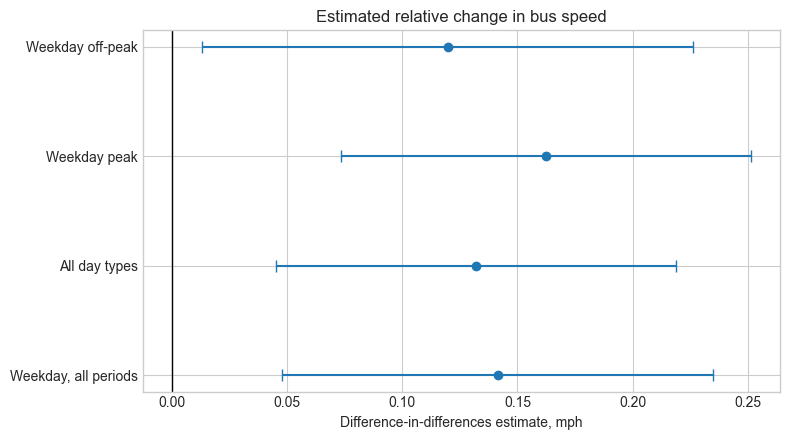

Primary estimate: +0.1414 mph (SE 0.0477, p=0.003022, 95% CI [0.0479, 0.2349]).


In [10]:
display(results.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_results = results.set_index("sample")
ax.errorbar(
    plot_results["estimate_mph"],
    plot_results.index,
    xerr=[
        plot_results["estimate_mph"] - plot_results["ci_low"],
        plot_results["ci_high"] - plot_results["estimate_mph"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Estimated relative change in bus speed")
ax.set_xlabel("Difference-in-differences estimate, mph")
fig.tight_layout()
plt.show()

primary = results.iloc[0]
print(
    f"Primary estimate: {primary['estimate_mph']:+.4f} mph "
    f"(SE {primary['std_error']:.4f}, p={primary['p_value']:.4g}, "
    f"95% CI [{primary['ci_low']:.4f}, {primary['ci_high']:.4f}])."
)

Within common propensity-score support, the primary weekday estimate is **+0.1414 mph** (SE 0.0477, p = 0.003; 95% CI [0.0479, 0.2349]). The estimates remain positive for all day types, peak service, and off-peak service.

The result describes a modest relative increase in bus speed for treated routes after January 2025. Overlap is adequate after trimming, and the distance diagnostic finds no evidence of a local spillover gradient.

## Part II. NYC Robustness and Boston External-Control Stress Test

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from nyc_common_support import compute_common_support
PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"

NYC_PANEL = PROCESSED / "nyc_did_panel_geojson_intersection.csv"
NYC_ROBUSTNESS = TABLES / "nyc_treatment_definition_robustness.csv"
BOSTON_PANEL = PROCESSED / "boston_bus_speeds_monthly.csv"
BOSTON_COMPARISON_OUTPUT = TABLES / "nyc_vs_boston_external_control_robustness.csv"
OFFICIAL_EQUIVALENCE = TABLES / "nyc_old_official_treatment_equivalence_audit.csv"

POLICY_MONTH = pd.Timestamp("2025-01-01")
ANALYSIS_START = pd.Timestamp("2023-08-01")
ANALYSIS_END = pd.Timestamp("2026-05-01")

pd.set_option("display.max_columns", 80)
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

### 2.1 Treatment-Definition and Sample Robustness

Threshold definitions are stricter robustness checks based on the maximum route-shape share inside the CBD.

In [12]:
robustness = pd.read_csv(NYC_ROBUSTNESS)
official_equivalence = pd.read_csv(OFFICIAL_EQUIVALENCE)
display(official_equivalence)
robustness.head(10)

,analysis_routes,geojson_treated_routes,old_official_treated_routes,mismatched_routes,identical_in_common_support_sample,interpretation
0,263,81,81,0,True,Mechanical duplicate; excluded from robustness...


,sample,treatment_column,treatment_definition,common_support_sample,estimate_mph,std_error,p_value,ci_low,ci_high,rows,routes,treated_routes,control_routes
0,weekday_all_periods,any_intersection,GeoJSON any policy-date route shape intersects...,True,0.141398,0.047682,0.003022,0.047942,0.234854,17815,263,81,182
1,weekday_all_periods,max_share_ge_05pct,GeoJSON max shape share in CBD >= 5%,True,0.142006,0.048691,0.003540,0.046571,0.237441,17815,263,79,184
2,weekday_all_periods,max_share_ge_10pct,GeoJSON max shape share in CBD >= 10%,True,0.158684,0.050176,0.001564,0.060339,0.257028,17815,263,75,188
3,weekday_all_periods,max_share_ge_25pct,GeoJSON max shape share in CBD >= 25%,True,0.064760,0.072776,0.373550,-0.077882,0.207401,17815,263,33,230
4,weekday_all_periods,max_share_ge_50pct,GeoJSON max shape share in CBD >= 50%,True,0.016519,0.024378,0.498017,-0.031261,0.064299,17815,263,22,241
5,weekday_all_periods,max_share_ge_80pct,GeoJSON max shape share in CBD >= 80%,True,0.030505,0.026635,0.252082,-0.021700,0.082710,17815,263,15,248
6,all_day_types_all_periods,any_intersection,GeoJSON any policy-date route shape intersects...,True,0.132423,0.044453,0.002892,0.045296,0.219550,33827,263,81,182
7,all_day_types_all_periods,max_share_ge_05pct,GeoJSON max shape share in CBD >= 5%,True,0.135218,0.045493,0.002956,0.046052,0.224384,33827,263,79,184
8,all_day_types_all_periods,max_share_ge_10pct,GeoJSON max shape share in CBD >= 10%,True,0.152983,0.045896,0.000858,0.063027,0.242939,33827,263,75,188
9,all_day_types_all_periods,max_share_ge_25pct,GeoJSON max shape share in CBD >= 25%,True,0.104971,0.066341,0.113584,-0.025058,0.234999,33827,263,33,230


In [13]:
weekday = robustness[robustness["sample"].eq("weekday_all_periods")].copy()
weekday["estimate_label"] = weekday["treatment_column"].map({
    "any_intersection": "Any intersection",
    "max_share_ge_05pct": ">= 5% max share",
    "max_share_ge_10pct": ">= 10% max share",
    "max_share_ge_25pct": ">= 25% max share",
    "max_share_ge_50pct": ">= 50% max share",
    "max_share_ge_80pct": ">= 80% max share",
})
weekday[["estimate_label", "treated_routes", "control_routes", "estimate_mph", "std_error", "p_value", "ci_low", "ci_high"]]

,estimate_label,treated_routes,control_routes,estimate_mph,std_error,p_value,ci_low,ci_high
0,Any intersection,81,182,0.141398,0.047682,0.003022,0.047942,0.234854
1,>= 5% max share,79,184,0.142006,0.048691,0.003540,0.046571,0.237441
2,>= 10% max share,75,188,0.158684,0.050176,0.001564,0.060339,0.257028
3,>= 25% max share,33,230,0.064760,0.072776,0.373550,-0.077882,0.207401
4,>= 50% max share,22,241,0.016519,0.024378,0.498017,-0.031261,0.064299
5,>= 80% max share,15,248,0.030505,0.026635,0.252082,-0.021700,0.082710


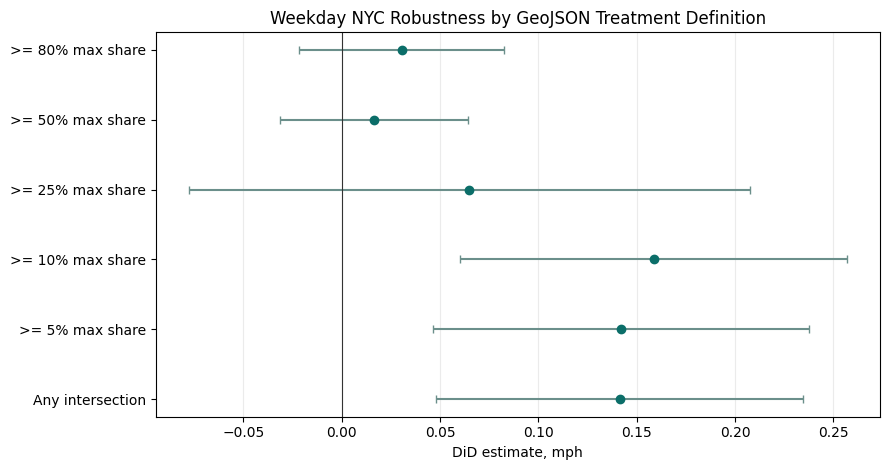

In [14]:
plot_df = weekday[weekday["treatment_column"].ne("old_official_source_union")].copy()
plot_df = plot_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(plot_df))
ax.errorbar(
    plot_df["estimate_mph"],
    y,
    xerr=[plot_df["estimate_mph"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["estimate_mph"]],
    fmt="o",
    color="#0b6e69",
    ecolor="#6b8f8b",
    capsize=3,
)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["estimate_label"])
ax.set_xlabel("DiD estimate, mph")
ax.set_title("Weekday NYC Robustness by GeoJSON Treatment Definition")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

**Takeaway.** On the common-support sample, the main any-intersection estimate remains positive. It is stable at the 5% threshold and slightly larger at 10%, then attenuates under stricter definitions that keep only routes with a large share inside the CBD. 

In [15]:
sample_summary = robustness.pivot_table(
    index="treatment_column",
    columns="sample",
    values="estimate_mph",
    aggfunc="first",
)
sample_summary

sample,all_day_types_all_periods,weekday_all_periods,weekday_off_peak,weekday_peak
treatment_column,,,,
any_intersection,0.132423,0.141398,0.119687,0.162311
max_share_ge_05pct,0.135218,0.142006,0.120764,0.162439
max_share_ge_10pct,0.152983,0.158684,0.135868,0.180675
max_share_ge_25pct,0.104971,0.064760,0.055094,0.074190
max_share_ge_50pct,0.055582,0.016519,0.026652,0.006140
max_share_ge_80pct,0.076194,0.030505,0.047943,0.012828


### 2.2 Strict Peak and Off-Peak Robustness

The focused check below holds service period strictly to Peak or Off-Peak weekday observations while retaining the main notebook's common-support route universe. Each row uses route fixed effects, month fixed effects, and route-clustered standard errors.

In [16]:
strict_periods = robustness[robustness["sample"].isin(["weekday_peak", "weekday_off_peak"])].copy()
strict_periods["estimate_label"] = strict_periods["treatment_column"].map({
    "any_intersection": "Any intersection",
    "max_share_ge_05pct": ">= 5% max share",
    "max_share_ge_10pct": ">= 10% max share",
    "max_share_ge_25pct": ">= 25% max share",
    "max_share_ge_50pct": ">= 50% max share",
    "max_share_ge_80pct": ">= 80% max share",
})
strict_periods[["sample", "estimate_label", "treated_routes", "control_routes", "estimate_mph", "std_error", "p_value", "ci_low", "ci_high"]]

,sample,estimate_label,treated_routes,control_routes,estimate_mph,std_error,p_value,ci_low,ci_high
12,weekday_peak,Any intersection,81,182,0.162311,0.045430,0.000353,0.073268,0.251354
13,weekday_peak,>= 5% max share,79,184,0.162439,0.046379,0.000461,0.071537,0.253342
14,weekday_peak,>= 10% max share,75,188,0.180675,0.047659,0.000150,0.087264,0.274087
15,weekday_peak,>= 25% max share,33,230,0.074190,0.065942,0.260560,-0.055057,0.203437
16,weekday_peak,>= 50% max share,22,241,0.006140,0.024748,0.804061,-0.042366,0.054646
17,weekday_peak,>= 80% max share,15,248,0.012828,0.028074,0.647730,-0.042198,0.067853
18,weekday_off_peak,Any intersection,81,182,0.119687,0.054410,0.027827,0.013043,0.226331
19,weekday_off_peak,>= 5% max share,79,184,0.120764,0.055584,0.029808,0.011819,0.229709
20,weekday_off_peak,>= 10% max share,75,188,0.135868,0.057445,0.018021,0.023276,0.248460
21,weekday_off_peak,>= 25% max share,33,230,0.055094,0.084002,0.511911,-0.109550,0.219739


#### Current run: strict-period conclusion

On the common-support sample, the any-intersection estimate is **+0.162 mph** in Peak service (p < 0.001) and **+0.120 mph** in Off-Peak service (p = 0.028). The 5% and 10% thresholds produce similar positive estimates in both periods. At the 25%, 50%, and 80% thresholds, estimates are smaller and not statistically distinguishable from zero at conventional levels. The positive result is therefore robust to Peak/Off-Peak sampling and modest threshold changes, but not to definitions that retain only routes with very high CBD shape shares.

### 2.3 Boston External-Control Stress Test

This section asks whether the NYC CBD speed gain is still visible when the comparison group is Boston MBTA bus routes rather than NYC non-CBD routes.

Construction choices:

- NYC sample: CBD-treated NYC routes only, weekday rows, August 2023 through May 2026.
- Boston sample: all processed MBTA routes, weekday rows, same months.
- Unit of observation: route-month-period after aggregating duplicate rows within each route/month/period.
- Model: `average_speed ~ did + route fixed effects + month fixed effects + period fixed effects`, clustered by route/unit.

This is deliberately labeled a stress test because Boston is an external city with different measurement and network structure.

In [17]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")


def build_nyc_cbd_external_panel():
    nyc = pd.read_csv(NYC_PANEL)
    nyc["month"] = pd.to_datetime(nyc["month"])
    support_audit = compute_common_support(nyc)
    common_support_routes = set(
        support_audit.loc[support_audit["in_common_support"], "route_id"]
    )
    nyc = nyc[
        nyc["month"].between(ANALYSIS_START, ANALYSIS_END)
        & nyc["route_id"].isin(common_support_routes)
        & nyc["day_type"].astype(str).eq("1")
        & nyc["cbd_route"].astype(bool)
    ].copy()
    nyc["total_mileage"] = clean_numeric(nyc["total_mileage"])
    nyc["total_operating_time"] = clean_numeric(nyc["total_operating_time"])
    grouped = (
        nyc.groupby(["month", "route_id", "period"], as_index=False)
        .agg(
            total_distance_miles=("total_mileage", "sum"),
            total_runtime_hours=("total_operating_time", "sum"),
        )
    )
    grouped["average_speed"] = grouped["total_distance_miles"] / grouped["total_runtime_hours"]
    grouped["unit_id"] = "NYC_CBD_" + grouped["route_id"].astype(str)
    grouped["city_group"] = "NYC CBD routes"
    grouped["treated"] = True
    grouped["post"] = grouped["month"].ge(POLICY_MONTH)
    return grouped


def build_boston_external_panel():
    boston = pd.read_csv(BOSTON_PANEL)
    boston["month"] = pd.to_datetime(boston["month"])
    boston = boston[
        boston["month"].between(ANALYSIS_START, ANALYSIS_END)
        & boston["day_type"].eq("Weekday")
    ].copy()
    grouped = (
        boston.groupby(["month", "route_id", "period"], as_index=False)
        .agg(
            total_distance_miles=("total_distance_miles", "sum"),
            total_runtime_hours=("total_runtime_hours", "sum"),
        )
    )
    grouped["average_speed"] = grouped["total_distance_miles"] / grouped["total_runtime_hours"]
    grouped["unit_id"] = "BOSTON_" + grouped["route_id"].astype(str)
    grouped["city_group"] = "Boston routes"
    grouped["treated"] = False
    grouped["post"] = grouped["month"].ge(POLICY_MONTH)
    return grouped

nyc_external = build_nyc_cbd_external_panel()
boston_external = build_boston_external_panel()
external_panel = pd.concat([nyc_external, boston_external], ignore_index=True)
external_panel = external_panel.dropna(subset=["average_speed", "total_runtime_hours"])
external_panel["did"] = external_panel["treated"].astype(int) * external_panel["post"].astype(int)

external_panel.groupby("city_group").agg(
    rows=("average_speed", "size"),
    routes=("unit_id", "nunique"),
    months=("month", "nunique"),
    mean_speed=("average_speed", "mean"),
    total_distance_miles=("total_distance_miles", "sum"),
)

,rows,routes,months,mean_speed,total_distance_miles
city_group,,,,,
Boston routes,9253,143,34,11.889809,3.832088e+07
NYC CBD routes,5414,81,34,9.378703,3.961956e+07


In [18]:
external_model = smf.ols(
    "average_speed ~ did + C(unit_id) + C(month) + C(period)",
    data=external_panel,
).fit(cov_type="cluster", cov_kwds={"groups": external_panel["unit_id"]})

external_result = pd.DataFrame([
    {
        "comparison": "NYC CBD routes vs Boston routes",
        "sample": "weekday_all_periods",
        "estimate_mph": external_model.params["did"],
        "std_error": external_model.bse["did"],
        "p_value": external_model.pvalues["did"],
        "ci_low": external_model.params["did"] - 1.96 * external_model.bse["did"],
        "ci_high": external_model.params["did"] + 1.96 * external_model.bse["did"],
        "rows": len(external_panel),
        "units": external_panel["unit_id"].nunique(),
        "nyc_cbd_units": nyc_external["unit_id"].nunique(),
        "boston_units": boston_external["unit_id"].nunique(),
    }
])
external_result.to_csv(BOSTON_COMPARISON_OUTPUT, index=False)
external_result

,comparison,sample,estimate_mph,std_error,p_value,ci_low,ci_high,rows,units,nyc_cbd_units,boston_units
0,NYC CBD routes vs Boston routes,weekday_all_periods,0.462039,0.061839,7.922708e-14,0.340834,0.583244,14667,224,81,143


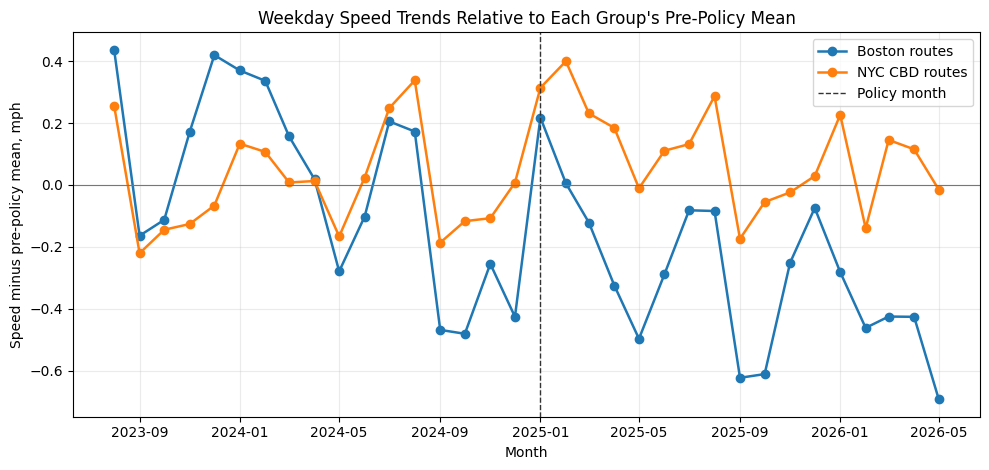

In [19]:
trend = (
    external_panel.groupby(["city_group", "month"], as_index=False)
    .agg(
        total_distance_miles=("total_distance_miles", "sum"),
        total_runtime_hours=("total_runtime_hours", "sum"),
    )
)
trend["average_speed"] = trend["total_distance_miles"] / trend["total_runtime_hours"]
pre_mean = trend[trend["month"].lt(POLICY_MONTH)].groupby("city_group")["average_speed"].mean()
trend["indexed_speed"] = trend.apply(lambda row: row["average_speed"] - pre_mean.loc[row["city_group"]], axis=1)

fig, ax = plt.subplots(figsize=(10, 4.8))
for group, group_df in trend.groupby("city_group"):
    ax.plot(group_df["month"], group_df["indexed_speed"], marker="o", linewidth=1.8, label=group)
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("Weekday Speed Trends Relative to Each Group's Pre-Policy Mean")
ax.set_ylabel("Speed minus pre-policy mean, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**Boston stress-test interpretation.** If the Boston comparison estimate has the same sign and broad magnitude as the main NYC control-route DiD, it gives some reassurance that the post-policy NYC CBD speed increase is not simply an artifact of using NYC non-CBD controls. If it differs sharply, that does not automatically invalidate the main design, because Boston is not a treated/control contrast within the same transit system.

In [20]:
print(f"Saved Boston external-control result to: {BOSTON_COMPARISON_OUTPUT.relative_to(ROOT)}")
print(f"Saved NYC threshold robustness table at: {NYC_ROBUSTNESS.relative_to(ROOT)}")

Saved Boston external-control result to: outputs\tables\nyc_vs_boston_external_control_robustness.csv
Saved NYC threshold robustness table at: outputs\tables\nyc_treatment_definition_robustness.csv


## Part III. NYC CBD Synthetic Control with NTD Donor Agencies

The treated unit is the **NYC CBD-exposed route network within the main DiD common-support sample**. The primary definition is `cbd_route = True` when any retained route shape intersects the CBD geofence. 

The treated NYC series is mileage-weighted network speed, computed as total mileage divided by total operating time. NTD donors are non-NYC-area fixed-route bus agencies using modes `MB`, `RB`, and `TB`.

In [21]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from nyc_common_support import compute_common_support
RAW_NTD = ROOT / "data" / "raw" / "NTD" / "May 2026 Complete Monthly Ridership (with adjustments and estimates)_260701.xlsx"
NYC_PANEL = ROOT / "data" / "processed" / "nyc_did_panel_geojson_intersection.csv"
PROCESSED = ROOT / "data" / "processed"
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"

POLICY_MONTH = pd.Timestamp("2025-01-01")
ANALYSIS_START = pd.Timestamp("2023-08-01")
ANALYSIS_END = pd.Timestamp("2026-05-01")

FIXED_ROUTE_BUS_MODES = ["MB", "RB", "TB"]
MAX_DONORS = 35  # Middle-ground cap; compare 30, 35, and 45 donors in the script sensitivity.

PROCESSED.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)

### 3.1 Build the Treated NYC CBD Network Series

Before aggregation, the notebook reproduces the main DiD propensity-score common-support trim and retains the 81 any-intersection routes that survive it. The monthly treated outcome is total mileage divided by total operating time across those weekday route rows.

In [22]:
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

nyc = pd.read_csv(NYC_PANEL)
nyc["month"] = pd.to_datetime(nyc["month"])
nyc["total_mileage"] = clean_numeric(nyc["total_mileage"])
nyc["total_operating_time"] = clean_numeric(nyc["total_operating_time"])

support_audit = compute_common_support(nyc)
common_support_routes = set(
    support_audit.loc[support_audit["in_common_support"], "route_id"]
)
nyc = nyc.loc[nyc["route_id"].isin(common_support_routes)].copy()

nyc_treated = nyc[
    nyc["month"].between(ANALYSIS_START, ANALYSIS_END)
    & nyc["day_type"].astype(str).eq("1")
    & nyc["cbd_route"].astype(bool)
].copy()

nyc_network = (
    nyc_treated.groupby("month", as_index=False)
    .agg(
        total_mileage=("total_mileage", "sum"),
        total_operating_time=("total_operating_time", "sum"),
        route_count=("route_id", "nunique"),
        rows=("route_id", "size"),
    )
)
nyc_network["average_speed"] = nyc_network["total_mileage"] / nyc_network["total_operating_time"]
nyc_network["unit_id"] = "NYC_CBD_ROUTES"
nyc_network["unit_name"] = "NYC CBD-treated route network"
nyc_network["post"] = nyc_network["month"].ge(POLICY_MONTH)
nyc_network.head()

,month,total_mileage,total_operating_time,route_count,rows,average_speed,unit_id,unit_name,post
0,2023-08-01,1.334371e+06,172071.779298,81,162,7.754732,NYC_CBD_ROUTES,NYC CBD-treated route network,False
1,2023-09-01,1.006494e+06,138284.816642,81,162,7.278416,NYC_CBD_ROUTES,NYC CBD-treated route network,False
2,2023-10-01,1.227570e+06,166919.170917,81,161,7.354276,NYC_CBD_ROUTES,NYC CBD-treated route network,False
3,2023-11-01,1.148115e+06,155723.085907,81,162,7.372800,NYC_CBD_ROUTES,NYC CBD-treated route network,False
4,2023-12-01,1.050851e+06,141385.818803,81,162,7.432508,NYC_CBD_ROUTES,NYC CBD-treated route network,False


In [23]:
nyc_network.agg(
    months=("month", "nunique"),
    mean_speed=("average_speed", "mean"),
    min_speed=("average_speed", "min"),
    max_speed=("average_speed", "max"),
    mean_routes=("route_count", "mean"),
)

,month,average_speed,route_count
months,34.0,NaN,NaN
mean_speed,NaN,7.550587,NaN
min_speed,NaN,7.278416,NaN
max_speed,NaN,7.898639,NaN
mean_routes,NaN,NaN,79.705882


### 3.2 Build NTD Agency-Level Bus-Speed Donors

The NTD workbook stores monthly measures in wide format. This section reads `VRM` and `VRH`, keeps fixed-route bus modes, aggregates across type of service for each agency/month, and computes:

`average_speed = bus_vrm / bus_vrh`

Modes retained:

- `MB`: motor bus
- `RB`: bus rapid transit
- `TB`: trolleybus

The primary donor definition excludes commuter bus (`CB`), demand response, and vanpool because those services are less comparable to street-running urban fixed-route bus service.


In [24]:
def normalize_ntd_id(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text.zfill(5) if text.isdigit() else text


def read_ntd_measure(sheet_name: str, value_name: str) -> pd.DataFrame:
    df = pd.read_excel(
        RAW_NTD,
        sheet_name=sheet_name,
        engine="openpyxl",
        dtype={"NTD ID": str, "Legacy NTD ID": str},
    )
    id_cols = [
        "NTD ID",
        "Legacy NTD ID",
        "Agency",
        "Mode/Type of Service Status",
        "Reporter Type",
        "UACE CD",
        "UZA Name",
        "Mode",
        "TOS",
        "3 Mode",
    ]
    month_cols = [c for c in df.columns if isinstance(c, str) and "/" in c and c.split("/")[-1].isdigit()]
    long = df.melt(id_vars=id_cols, value_vars=month_cols, var_name="month_label", value_name=value_name)
    long["month"] = pd.to_datetime(long["month_label"], format="%m/%Y", errors="coerce")
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")
    long["ntd_id"] = long["NTD ID"].map(normalize_ntd_id)
    return long.drop(columns=["NTD ID", "month_label"])

vrm = read_ntd_measure("VRM", "bus_vrm")
vrh = read_ntd_measure("VRH", "bus_vrh")

merge_keys = [
    "ntd_id",
    "Legacy NTD ID",
    "Agency",
    "Mode/Type of Service Status",
    "Reporter Type",
    "UACE CD",
    "UZA Name",
    "Mode",
    "TOS",
    "3 Mode",
    "month",
]
ntd_long = vrm.merge(vrh, on=merge_keys, how="inner")
ntd_long = ntd_long[
    ntd_long["month"].between(ANALYSIS_START, ANALYSIS_END)
    & ntd_long["Mode/Type of Service Status"].eq("Active")
    & ntd_long["Mode"].isin(FIXED_ROUTE_BUS_MODES)
].copy()

ntd_monthly = (
    ntd_long.groupby(
        [
            "ntd_id",
            "Legacy NTD ID",
            "Agency",
            "Reporter Type",
            "UACE CD",
            "UZA Name",
            "month",
        ],
        as_index=False,
    )
    .agg(
        bus_vrm=("bus_vrm", "sum"),
        bus_vrh=("bus_vrh", "sum"),
        modes=("Mode", lambda values: ";".join(sorted(set(values.dropna())))),
        active_mode_rows=("Mode/Type of Service Status", lambda values: int(values.eq("Active").sum())),
    )
)
ntd_monthly = ntd_monthly[(ntd_monthly["bus_vrm"] > 0) & (ntd_monthly["bus_vrh"] > 0)].copy()
ntd_monthly["average_speed"] = ntd_monthly["bus_vrm"] / ntd_monthly["bus_vrh"]
ntd_monthly.to_csv(PROCESSED / "ntd_monthly_bus_speeds.csv", index=False)
ntd_monthly.head()


,ntd_id,Legacy NTD ID,Agency,Reporter Type,UACE CD,UZA Name,month,bus_vrm,bus_vrh,modes,active_mode_rows,average_speed
0,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-08-01,2868968.0,280239.0,MB;TB,3,10.237576
1,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-09-01,2694260.0,262438.0,MB;TB,3,10.266272
2,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-10-01,2829957.0,275975.0,MB;TB,3,10.254396
3,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-11-01,2725486.0,265853.0,MB;TB,3,10.251853
4,00001,0001,King County,Full Reporter,80389.0,"Seattle--Tacoma, WA",2023-12-01,2751504.0,268297.0,MB;TB,3,10.255441


### 3.3 Exclude NYC-Area Agencies and Select Donors

The donor pool must not include anything in the NYC area. The filter below excludes:

- any agency in the `New York--Jersey City--Newark, NY--NJ` urbanized area;
- agency names containing NYC-area rail/transit keywords such as `MTA`, `New York`, `NJ Transit`, `PATH`, `Port Authority`, `Long Island`, `Metro-North`, or `Jersey`.

After exclusion, the notebook keeps agencies with full monthly coverage across Aug 2023-May 2026 and selects the largest agencies by pre-period bus VRM. The primary donor pool is capped at the 35 largest eligible agencies by pre-period VRM. Because there are only 17 pre-policy months, the accompanying script compares 30, 35, and 45 donors; fit quality and post-policy gaps are interpreted jointly rather than treating any one donor count as uniquely selected.

In [25]:
NYC_AREA_UZA_PATTERN = "NEW YORK--JERSEY CITY--NEWARK"
NYC_AREA_AGENCY_KEYWORDS = [
    "MTA",
    "NEW YORK",
    "NJ TRANSIT",
    "NEW JERSEY",
    "PORT AUTHORITY",
    "PATH",
    "LONG ISLAND",
    "METRO-NORTH",
    "JERSEY",
    "NEWARK",
]

all_months = pd.date_range(ANALYSIS_START, ANALYSIS_END, freq="MS")
pre_months = all_months[all_months < POLICY_MONTH]
post_months = all_months[all_months >= POLICY_MONTH]

agency_meta = (
    ntd_monthly.groupby(["ntd_id", "Agency", "UZA Name", "Reporter Type"], as_index=False)
    .agg(
        months=("month", "nunique"),
        pre_vrm=("bus_vrm", lambda values: values[ntd_monthly.loc[values.index, "month"].lt(POLICY_MONTH)].sum()),
        mean_speed=("average_speed", "mean"),
    )
)
agency_meta["agency_upper"] = agency_meta["Agency"].str.upper()
agency_meta["uza_upper"] = agency_meta["UZA Name"].str.upper()
agency_meta["excluded_nyc_area"] = agency_meta["uza_upper"].str.contains(NYC_AREA_UZA_PATTERN, regex=False, na=False)
for keyword in NYC_AREA_AGENCY_KEYWORDS:
    agency_meta["excluded_nyc_area"] |= agency_meta["agency_upper"].str.contains(keyword, regex=False, na=False)

agency_meta["full_window"] = agency_meta["months"].eq(len(all_months))
agency_meta["eligible_donor"] = agency_meta["full_window"] & ~agency_meta["excluded_nyc_area"]

excluded = agency_meta[agency_meta["excluded_nyc_area"]].sort_values(["UZA Name", "Agency"])
excluded.to_csv(TABLES / "ntd_synthetic_control_excluded_nyc_area_agencies.csv", index=False)

eligible = agency_meta[agency_meta["eligible_donor"]].copy()
selected_donors = eligible.sort_values("pre_vrm", ascending=False).head(MAX_DONORS).copy()
selected_donors.to_csv(TABLES / "ntd_synthetic_control_donor_pool.csv", index=False)

print(f"Analysis months: {len(all_months)} ({all_months.min().date()} to {all_months.max().date()})")
print(f"Eligible non-NYC donors with full coverage: {len(eligible)}")
print(f"Selected donors used in optimization: {len(selected_donors)}")
selected_donors[["ntd_id", "Agency", "UZA Name", "pre_vrm", "mean_speed"]].head(15)

Analysis months: 34 (2023-08-01 to 2026-05-01)
Eligible non-NYC donors with full coverage: 330
Selected donors used in optimization: 35


,ntd_id,Agency,UZA Name,pre_vrm,mean_speed
376,90154,Los Angeles County Metropolitan Transportation...,"Los Angeles--Long Beach--Anaheim, CA",100590040.0,10.217340
233,50066,Chicago Transit Authority,"Chicago, IL--IN",68740740.0,9.092513
92,30030,Washington Metropolitan Area Transit Authority,"Washington--Arlington, DC--VA--MD",54734133.0,9.719218
88,30019,Southeastern Pennsylvania Transportation Autho...,"Philadelphia, PA--NJ--DE--MD",53796293.0,10.201184
261,60008,Metropolitan Transit Authority of Harris Count...,"Houston, TX",53085099.0,12.604594
0,00001,King County,"Seattle--Tacoma, WA",48252837.0,10.089907
317,80006,Denver Regional Transportation District,"Denver--Aurora, CO",36379016.0,12.006142
279,60056,Dallas Area Rapid Transit,"Dallas--Fort Worth--Arlington, TX",36116257.0,12.857684
145,40034,County of Miami-Dade,"Miami--Fort Lauderdale, FL",34637730.0,12.231778
135,40022,Metropolitan Atlanta Rapid Transit Authority,"Atlanta, GA",34330773.0,12.736242


In [26]:
excluded[["ntd_id", "Agency", "UZA Name", "months", "mean_speed"]].head(25)

,ntd_id,Agency,UZA Name,months,mean_speed
74,20192,Bergen County,"New York--Jersey City--Newark, NY--NJ",5,8.460937
57,20006,City of Long Beach,"New York--Jersey City--Newark, NY--NJ",34,9.288452
76,20206,County of Nassau,"New York--Jersey City--Newark, NY--NJ",34,10.327304
66,20084,County of Rockland,"New York--Jersey City--Newark, NY--NJ",34,18.072251
72,20188,MTA Bus Company,"New York--Jersey City--Newark, NY--NJ",34,7.739950
58,20008,MTA New York City Transit,"New York--Jersey City--Newark, NY--NJ",34,7.001370
64,20078,"Metro-North Commuter Railroad Company, dba: MT...","New York--Jersey City--Newark, NY--NJ",34,5.458412
65,20080,New Jersey Transit Corporation,"New York--Jersey City--Newark, NY--NJ",33,14.018400
73,20190,Port Imperial Ferry Corporation,"New York--Jersey City--Newark, NY--NJ",33,6.743303
70,20175,Private Transportation Corporation,"New York--Jersey City--Newark, NY--NJ",34,9.505081


### 3.4 Prepare the Synthetic-Control Outcome Matrix

Because the treated series is route-network speed while NTD donors are agency-network speeds, the primary outcome is **pre-mean-centered mph**, so this is trajectory/change matching rather than conventional level-matching synthetic control:

`centered_speed = average_speed - each unit's pre-period mean speed`

This preserves month-to-month speed changes in mph while removing persistent level differences across agencies. The final effect can be read as a post-policy change in NYC CBD speed relative to a weighted donor counterfactual, in mph deviations from baseline.

In [27]:
donor_panel = ntd_monthly[ntd_monthly["ntd_id"].isin(selected_donors["ntd_id"])].copy()
donor_panel["unit_id"] = donor_panel["ntd_id"]
donor_panel["unit_name"] = donor_panel["Agency"]
donor_panel = donor_panel[["month", "unit_id", "unit_name", "average_speed", "bus_vrm", "bus_vrh"]]

treated_panel = nyc_network[["month", "unit_id", "unit_name", "average_speed"]].copy()
treated_panel["bus_vrm"] = np.nan
treated_panel["bus_vrh"] = np.nan

synth_panel = pd.concat([treated_panel, donor_panel], ignore_index=True)
pre_means = synth_panel[synth_panel["month"].lt(POLICY_MONTH)].groupby("unit_id")["average_speed"].mean()
synth_panel["pre_mean_speed"] = synth_panel["unit_id"].map(pre_means)
synth_panel["centered_speed"] = synth_panel["average_speed"] - synth_panel["pre_mean_speed"]
synth_panel["post"] = synth_panel["month"].ge(POLICY_MONTH)

wide = synth_panel.pivot(index="month", columns="unit_id", values="centered_speed").sort_index()
wide = wide.loc[all_months]
treated_id = "NYC_CBD_ROUTES"
donor_ids = selected_donors["ntd_id"].tolist()

Y_treated_pre = wide.loc[pre_months, treated_id].to_numpy()
X_donors_pre = wide.loc[pre_months, donor_ids].to_numpy()
Y_treated_all = wide[treated_id].to_numpy()
X_donors_all = wide[donor_ids].to_numpy()

assert not np.isnan(Y_treated_pre).any()
assert not np.isnan(X_donors_pre).any()
assert not np.isnan(X_donors_all).any()
wide.head()

unit_id,00001,00008,10003,30019,30022,30030,30068,40022,40029,40034,40035,50008,50012,50015,50016,50027,50066,50113,60008,60011,60048,60056,70006,80001,80006,90002,90013,90014,90015,90026,90036,90045,90136,90146,90154,NYC_CBD_ROUTES
2023-08-01,0.157586,0.000888,0.176937,-0.257521,0.037420,0.022622,-0.065024,0.040069,0.252686,0.944953,0.161382,0.095619,-0.301752,-0.071335,-0.014938,-0.000086,-0.009767,-0.215818,0.032495,0.214215,0.052739,0.655765,0.220619,0.203701,0.094493,0.007608,0.073664,0.147374,0.013419,-0.105183,-0.264139,-0.030572,0.016246,-0.047773,-0.001887,0.255808
2023-09-01,0.186283,0.053068,0.045730,0.284710,0.066462,0.018306,-0.077977,0.009938,0.268243,1.023327,0.200434,0.153004,-0.384513,-0.040431,-0.173954,0.075639,0.031227,-0.080721,0.043788,0.201586,0.031887,0.388109,0.243237,0.010061,0.111573,0.073583,0.041254,0.146541,0.022394,-0.043155,-0.053310,0.005079,0.014617,0.006360,0.027093,-0.220508
2023-10-01,0.174407,0.014374,0.039528,0.320858,0.072441,0.165291,-0.081925,-0.005899,0.156498,0.989510,0.184458,0.112773,-0.375962,-0.047261,-0.177080,0.242006,0.032075,-0.022169,0.059351,0.142224,-0.034837,0.218389,0.213806,0.024217,0.091308,0.148371,0.042592,0.137618,-0.005366,-0.005739,-0.064528,0.047866,0.114622,-0.013338,0.015872,-0.144648
2023-11-01,0.171864,-0.020249,0.065852,-0.097660,0.076974,0.166870,-0.095145,0.013870,0.072515,0.174286,0.087562,0.106357,-0.374812,-0.048620,-0.151505,0.228308,0.035957,-0.028296,0.075581,0.217874,0.039405,-0.610147,0.207294,0.006859,0.095624,0.357378,0.024679,0.136169,0.018622,0.027408,-0.036037,0.080631,-0.241808,-0.053300,0.024360,-0.126124
2023-12-01,0.175451,0.004679,0.118017,-0.070378,0.092951,0.064196,-0.082320,0.045259,0.085366,-0.253276,-1.058908,0.034121,-0.319487,-0.036025,-0.239331,0.042007,0.047954,-0.027158,0.081843,0.332915,0.121234,-0.789867,0.091069,0.009912,0.118637,0.029126,0.026702,-1.537256,0.035231,0.033299,-0.003955,0.018886,-0.002119,-0.022450,0.033131,-0.066416


### 3.5 Fit Synthetic-Control Weights

Weights are constrained to be nonnegative and sum to one. The optimizer minimizes pre-period mean squared prediction error.

In [28]:
def fit_synth_weights(X_pre: np.ndarray, y_pre: np.ndarray) -> np.ndarray:
    n = X_pre.shape[1]
    x0 = np.repeat(1 / n, n)

    def objective(w):
        residual = y_pre - X_pre @ w
        return float(np.mean(residual ** 2))

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)
    bounds = [(0, 1)] * n
    result = minimize(objective, x0=x0, method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        raise RuntimeError(result.message)
    weights = result.x
    weights[weights < 1e-10] = 0
    weights = weights / weights.sum()
    return weights

weights = fit_synth_weights(X_donors_pre, Y_treated_pre)
synthetic_all = X_donors_all @ weights
result = pd.DataFrame({
    "month": all_months,
    "treated_centered_speed": Y_treated_all,
    "synthetic_centered_speed": synthetic_all,
})
result["gap_mph"] = result["treated_centered_speed"] - result["synthetic_centered_speed"]
result["post"] = result["month"].ge(POLICY_MONTH)

pre_rmspe = np.sqrt(np.mean(result.loc[~result["post"], "gap_mph"] ** 2))
post_mean_gap = result.loc[result["post"], "gap_mph"].mean()
post_mean_treated_change = result.loc[result["post"], "treated_centered_speed"].mean()
post_mean_synth_change = result.loc[result["post"], "synthetic_centered_speed"].mean()

summary = pd.DataFrame([
    {
        "outcome": "centered monthly average speed, mph",
        "treated_unit": "NYC CBD-treated route network",
        "treated_routes": int(nyc_treated["route_id"].nunique()),
        "donor_pool_size": len(donor_ids),
        "pre_months": len(pre_months),
        "post_months": len(post_months),
        "pre_rmspe": pre_rmspe,
        "post_mean_gap_mph": post_mean_gap,
        "post_mean_treated_change_mph": post_mean_treated_change,
        "post_mean_synthetic_change_mph": post_mean_synth_change,
        "bus_modes": ",".join(FIXED_ROUTE_BUS_MODES),
    }
])

result.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_monthly_results.csv", index=False)
summary.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_summary.csv", index=False)
summary

,outcome,treated_unit,treated_routes,donor_pool_size,pre_months,post_months,pre_rmspe,post_mean_gap_mph,post_mean_treated_change_mph,post_mean_synthetic_change_mph,bus_modes
0,"centered monthly average speed, mph",NYC CBD-treated route network,81,35,17,17,0.120851,0.137563,0.103326,-0.034238,"MB,RB,TB"


In [29]:
weights_table = selected_donors[["ntd_id", "Agency", "UZA Name", "pre_vrm", "mean_speed"]].copy()
weights_table["weight"] = weights
weights_table = weights_table.sort_values("weight", ascending=False)
weights_table.to_csv(TABLES / "nyc_cbd_ntd_synthetic_control_weights.csv", index=False)
weights_table[weights_table["weight"].gt(0.001)].head(20)

,ntd_id,Agency,UZA Name,pre_vrm,mean_speed,weight
201,50016,Central Ohio Transit Authority,"Columbus, OH",15290540.0,12.132275,0.420237
277,60048,Capital Metropolitan Transportation Authority,"Austin, TX",20467320.0,11.121251,0.354516
357,90045,Regional Transportation Commission of Southern...,"Las Vegas--Henderson--Paradise, NV",26120165.0,12.430849,0.106474
146,40035,Central Florida Regional Transportation Authority,"Orlando, FL",22750247.0,13.438463,0.038397
370,90136,Regional Public Transportation Authority,"Phoenix--Mesa--Scottsdale, AZ",16927921.0,12.121770,0.036592
100,30068,"Fairfax County, VA","Washington--Arlington, DC--VA--MD",15766721.0,13.398154,0.027075
199,50012,Southwest Ohio Regional Transit Authority,"Cincinnati, OH--KY",16043391.0,13.542989,0.016710


### 3.6 Visualize Fit and Post-Policy Gap

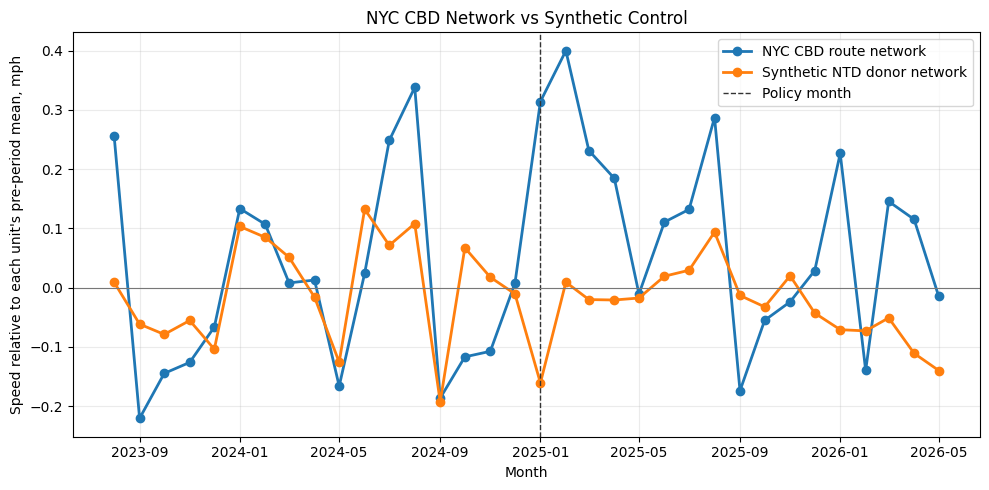

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(result["month"], result["treated_centered_speed"], marker="o", linewidth=2, label="NYC CBD route network")
ax.plot(result["month"], result["synthetic_centered_speed"], marker="o", linewidth=2, label="Synthetic NTD donor network")
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("NYC CBD Network vs Synthetic Control")
ax.set_ylabel("Speed relative to each unit's pre-period mean, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "nyc_cbd_ntd_synthetic_control_fit.png", dpi=220, bbox_inches="tight")
plt.show()

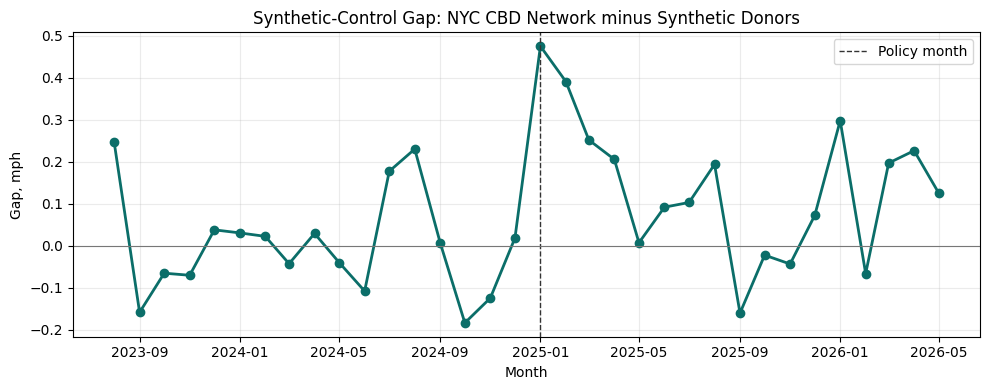

In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result["month"], result["gap_mph"], marker="o", linewidth=2, color="#0b6e69")
ax.axvline(POLICY_MONTH, color="#333333", linestyle="--", linewidth=1, label="Policy month")
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("Synthetic-Control Gap: NYC CBD Network minus Synthetic Donors")
ax.set_ylabel("Gap, mph")
ax.set_xlabel("Month")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "nyc_cbd_ntd_synthetic_control_gap.png", dpi=220, bbox_inches="tight")
plt.show()

### 3.7 Interpretation Guardrails

This design is most useful as a robustness exercise.

Strengths:

- donor pool is broad and built from a consistent national source;
- NYC-area agencies are excluded from the donor pool;
- weights are learned only from the pre-policy period;

Limitations:

- NTD donor speeds are agency-level, not CBD-like route-subnetwork speeds;
- the pre-period has only 17 months, so overfitting remains a concern even with a limited donor pool;

In [32]:
print("Saved outputs:")
for path in [
    PROCESSED / "ntd_monthly_bus_speeds.csv",
    TABLES / "ntd_synthetic_control_excluded_nyc_area_agencies.csv",
    TABLES / "ntd_synthetic_control_donor_pool.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_weights.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_monthly_results.csv",
    TABLES / "nyc_cbd_ntd_synthetic_control_summary.csv",
    FIGURES / "nyc_cbd_ntd_synthetic_control_fit.png",
    FIGURES / "nyc_cbd_ntd_synthetic_control_gap.png",
]:
    print(path.relative_to(ROOT))

Saved outputs:
data\processed\ntd_monthly_bus_speeds.csv
outputs\tables\ntd_synthetic_control_excluded_nyc_area_agencies.csv
outputs\tables\ntd_synthetic_control_donor_pool.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_weights.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_monthly_results.csv
outputs\tables\nyc_cbd_ntd_synthetic_control_summary.csv
outputs\figures\nyc_cbd_ntd_synthetic_control_fit.png
outputs\figures\nyc_cbd_ntd_synthetic_control_gap.png


### 3.8 Synthetic-Control Treatment-Definition Robustness

The primary synthetic control and every threshold variant use the main DiD common-support route universe. We repeat the exercise for the same CBD-share thresholds used in the NYC DiD robustness analysis while holding the NTD donor pool, fixed-route bus modes, analysis window, centering rule, and nonnegative sum-to-one constraint fixed.

In [33]:
SC_ROBUSTNESS = TABLES / "nyc_cbd_ntd_synthetic_control_robustness_summary.csv"
sc_robustness = pd.read_csv(SC_ROBUSTNESS)
sc_robustness[["treatment_column", "treatment_definition", "treated_routes", "donor_pool_size", "pre_rmspe", "post_mean_gap_mph", "post_mean_treated_change_mph", "post_mean_synthetic_change_mph"]]

,treatment_column,treatment_definition,treated_routes,donor_pool_size,pre_rmspe,post_mean_gap_mph,post_mean_treated_change_mph,post_mean_synthetic_change_mph
0,any_intersection,GeoJSON any policy-date route shape intersects...,81,35,0.120851,0.137563,0.103326,-0.034238
1,max_share_ge_05pct,GeoJSON max shape share in CBD >= 5%,79,35,0.126073,0.147039,0.102619,-0.044420
2,max_share_ge_10pct,GeoJSON max shape share in CBD >= 10%,75,35,0.121521,0.157128,0.110133,-0.046995
3,max_share_ge_25pct,GeoJSON max shape share in CBD >= 25%,33,35,0.062046,0.133631,0.097341,-0.036290
4,max_share_ge_50pct,GeoJSON max shape share in CBD >= 50%,22,35,0.056162,0.123273,0.100437,-0.022836
5,max_share_ge_80pct,GeoJSON max shape share in CBD >= 80%,15,35,0.056286,0.157306,0.108026,-0.049280


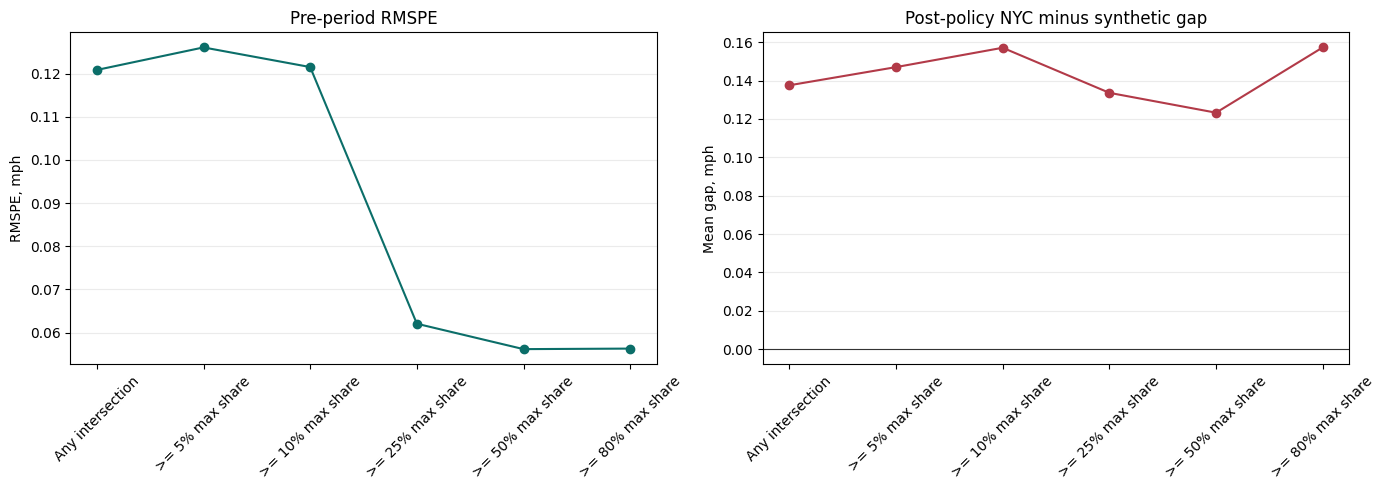

In [34]:
sc_plot = sc_robustness.copy()
sc_plot["label"] = sc_plot["treatment_column"].map({
    "any_intersection": "Any intersection",
    "max_share_ge_05pct": ">= 5% max share",
    "max_share_ge_10pct": ">= 10% max share",
    "max_share_ge_25pct": ">= 25% max share",
    "max_share_ge_50pct": ">= 50% max share",
    "max_share_ge_80pct": ">= 80% max share",
})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sc_plot["label"], sc_plot["pre_rmspe"], marker="o", color="#0b6e69")
axes[0].set_title("Pre-period RMSPE")
axes[0].set_ylabel("RMSPE, mph")
axes[1].plot(sc_plot["label"], sc_plot["post_mean_gap_mph"], marker="o", color="#b23a48")
axes[1].axhline(0, color="#333333", linewidth=0.8)
axes[1].set_title("Post-policy NYC minus synthetic gap")
axes[1].set_ylabel("Mean gap, mph")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

#### Interpretation

The synthetic-control robustness result is most reassuring when the post-policy gap remains positive while pre-period RMSPE stays reasonably small across the original treatment and nearby thresholds. The threshold exercise is descriptive: changing the treated network changes the target unit, so the gaps should be compared for sign, magnitude, and pre-fit quality rather than treated as independent causal estimates. Very strict thresholds may leave a small treated network and can worsen comparability or make the result unstable. The synthetic-control evidence therefore complements, but does not replace, the route-level NYC DiD.


#### Synthetic-control conclusion

Using the 81 common-support any-intersection routes, the 35-donor post-policy NYC-minus-synthetic gap is **+0.138 mph**, with pre-period RMSPE **0.121 mph**. The 5% and 10% definitions yield gaps of **+0.147 mph** and **+0.157 mph**. All stricter thresholds remain positive, although they define smaller treated networks and are not independent confirmations.

For the primary definition, 30 donors yield RMSPE **0.147 mph** and a **+0.127 mph** gap; the 35- and 45-donor specifications both yield RMSPE **0.121 mph** and a **+0.138 mph** gap because candidates beyond the selected 35 receive no effective weight. The old official union is absent from the grid because it exactly duplicates the primary route set in the common-support sample.